# Notebook 1 — Data Exploration

**Purpose:** Understand the raw TravisTorrent dataset before any transformation. This notebook loads the raw CSV and produces a clear picture of shape, columns, types, missingness, target distribution, and key numeric feature distributions. All plots are saved to `reports/figures` for the dissertation.

**Dataset:** TravisTorrent — historical Travis CI build records from GitHub projects (Al-Barhami et al., 2026). Target: `tr_status` (passed / failed / errored / canceled).

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

FIG_DIR = Path("../reports/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)
plt.rcParams["figure.figsize"] = (8, 5)
sns.set_theme(style="whitegrid")

### Load raw data

Load the TravisTorrent CSV from `data/raw`. Use `nrows` for faster iteration during development; remove it for full-dataset exploration.

In [36]:
df = pd.read_csv(
    "../data/raw/final-2017-01-25.csv",
    nrows=100000
)

df.shape

(100000, 66)

### Columns and data types

List all column names and inspect dtypes to understand the schema.

In [37]:
df.columns

Index(['tr_build_id', 'gh_project_name', 'gh_is_pr', 'gh_pr_created_at',
       'gh_pull_req_num', 'gh_lang', 'git_merged_with', 'git_branch',
       'gh_num_commits_in_push', 'gh_commits_in_push',
       'git_prev_commit_resolution_status', 'git_prev_built_commit',
       'tr_prev_build', 'gh_first_commit_created_at', 'gh_team_size',
       'git_all_built_commits', 'git_num_all_built_commits',
       'git_trigger_commit', 'tr_virtual_merged_into', 'gh_num_issue_comments',
       'gh_num_commit_comments', 'gh_num_pr_comments', 'git_diff_src_churn',
       'git_diff_test_churn', 'gh_diff_files_added', 'gh_diff_files_deleted',
       'gh_diff_files_modified', 'gh_diff_tests_added',
       'gh_diff_tests_deleted', 'gh_diff_src_files', 'gh_diff_doc_files',
       'gh_diff_other_files', 'gh_num_commits_on_files_touched', 'gh_sloc',
       'gh_test_lines_per_kloc', 'gh_test_cases_per_kloc',
       'gh_asserts_cases_per_kloc', 'gh_by_core_team_member',
       'gh_description_complexity', 'gh_

### Missing values

Count nulls per column. We also express missingness as a percentage of rows so we can prioritize which columns need handling in the processing notebook.

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 66 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   tr_build_id                        100000 non-null  int64  
 1   gh_project_name                    100000 non-null  object 
 2   gh_is_pr                           100000 non-null  bool   
 3   gh_pr_created_at                   0 non-null       float64
 4   gh_pull_req_num                    0 non-null       float64
 5   gh_lang                            100000 non-null  object 
 6   git_merged_with                    0 non-null       float64
 7   git_branch                         100000 non-null  object 
 8   gh_num_commits_in_push             0 non-null       float64
 9   gh_commits_in_push                 0 non-null       float64
 10  git_prev_commit_resolution_status  100000 non-null  object 
 11  git_prev_built_commit              81493

In [39]:
df.isnull().sum().sort_values(ascending=False)

gh_num_issue_comments              100000
gh_num_commits_in_push             100000
tr_log_setup_time                  100000
gh_num_pr_comments                 100000
gh_pushed_at                       100000
                                    ...  
gh_num_commits_on_files_touched         0
gh_project_name                         0
gh_test_lines_per_kloc                  0
gh_test_cases_per_kloc                  0
tr_jobs                                 0
Length: 66, dtype: int64

In [40]:
# Missing values as percentage of rows (for prioritization in Notebook 2)
missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
missing_pct[missing_pct > 0]

gh_num_issue_comments            100.000
gh_num_commits_in_push           100.000
tr_log_setup_time                100.000
gh_num_pr_comments               100.000
gh_pushed_at                     100.000
tr_virtual_merged_into           100.000
gh_first_commit_created_at       100.000
gh_commits_in_push               100.000
gh_description_complexity        100.000
git_merged_with                  100.000
gh_pull_req_num                  100.000
gh_pr_created_at                 100.000
tr_log_num_test_suites_run        99.961
tr_log_num_test_suites_failed     99.961
tr_log_num_test_suites_ok         99.961
tr_log_buildduration              99.716
tr_log_tests_failed               98.378
tr_log_num_tests_run              39.670
tr_log_frameworks                 39.600
tr_log_num_tests_skipped          38.474
tr_log_num_tests_ok               38.474
tr_log_testduration               38.253
tr_log_num_tests_failed           33.726
tr_log_bool_tests_failed          33.521
tr_prev_build   

### Target variable: build status

The target is `tr_status`: **passed**, **failed**, **errored**, or **canceled**. This is a multi-class classification problem. Below we show the distribution as counts, then as a bar chart and pie chart (saved to `reports/figures`).

In [41]:
df["tr_status"].value_counts()

tr_status
passed     60461
failed     36928
errored     2611
Name: count, dtype: int64

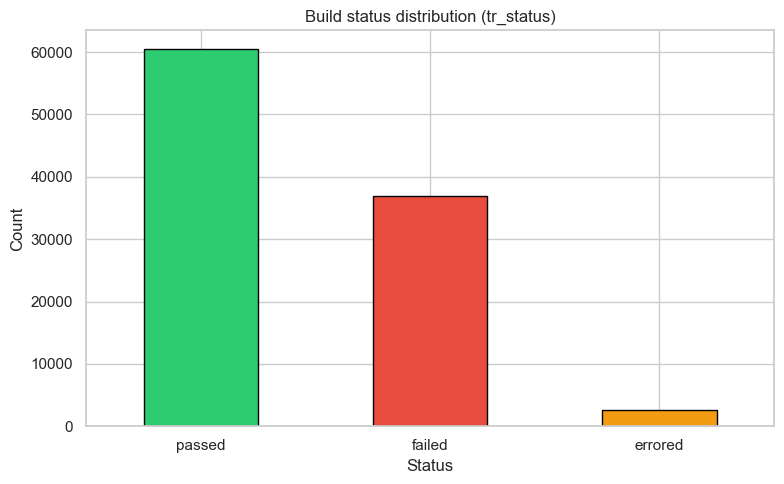

In [42]:
# Bar chart: target distribution
counts = df["tr_status"].value_counts()
ax = counts.plot(kind="bar", color=["#2ecc71", "#e74c3c", "#f39c12", "#95a5a6"], edgecolor="black")
ax.set_title("Build status distribution (tr_status)")
ax.set_ylabel("Count")
ax.set_xlabel("Status")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIG_DIR / "01_target_bar.png", dpi=150, bbox_inches="tight")
plt.show()

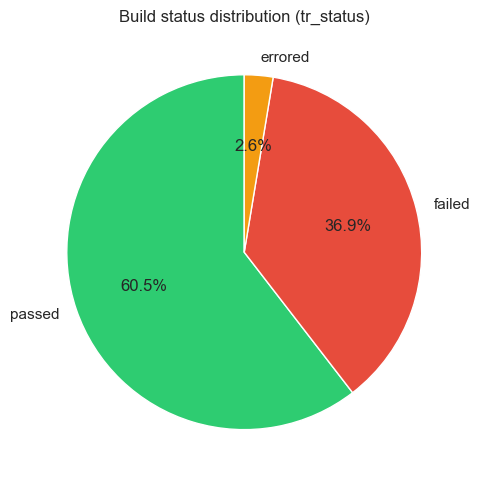

In [43]:
# Pie chart: target distribution
fig, ax = plt.subplots()
ax.pie(counts, labels=counts.index, autopct="%1.1f%%", startangle=90, colors=["#2ecc71", "#e74c3c", "#f39c12", "#95a5a6"])
ax.set_title("Build status distribution (tr_status)")
plt.tight_layout()
plt.savefig(FIG_DIR / "01_target_pie.png", dpi=150, bbox_inches="tight")
plt.show()

### Key numeric features

Histograms for build duration (`tr_duration`), number of commits per build (`git_num_all_built_commits`), and lines of code changed (source + test churn). These are among the most predictive signals identified in the literature (Kumar et al., 2025).

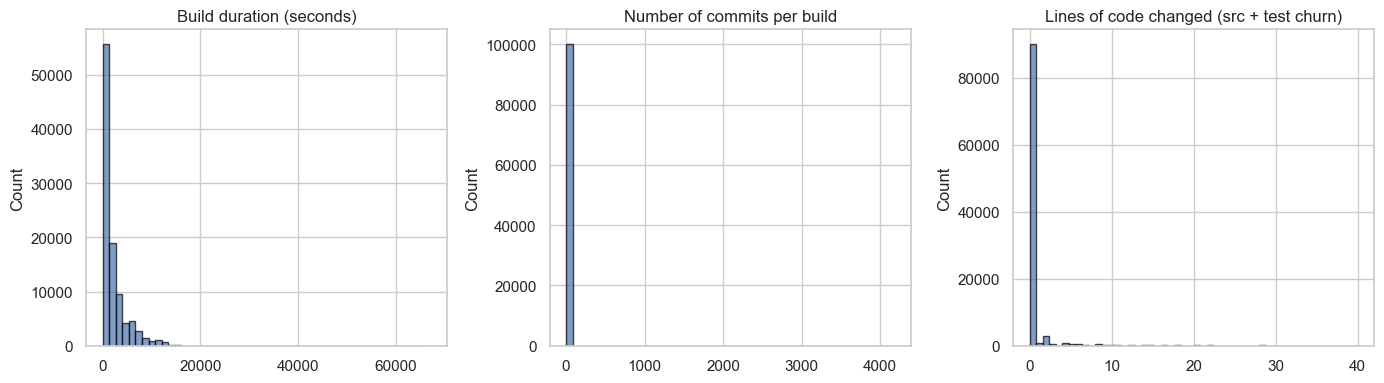

In [44]:
# Histograms for key numeric features
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
if "tr_duration" in df.columns:
    df["tr_duration"].dropna().hist(ax=axes[0], bins=50, edgecolor="black", alpha=0.7)
    axes[0].set_title("Build duration (seconds)")
    axes[0].set_ylabel("Count")
if "git_num_all_built_commits" in df.columns:
    df["git_num_all_built_commits"].hist(ax=axes[1], bins=50, edgecolor="black", alpha=0.7)
    axes[1].set_title("Number of commits per build")
    axes[1].set_ylabel("Count")
if "git_diff_src_churn" in df.columns and "git_diff_test_churn" in df.columns:
    loc_changed = df["git_diff_src_churn"].fillna(0) + df["git_diff_test_churn"].fillna(0)
    loc_changed[loc_changed < loc_changed.quantile(0.99)].hist(ax=axes[2], bins=50, edgecolor="black", alpha=0.7)
    axes[2].set_title("Lines of code changed (src + test churn)")
    axes[2].set_ylabel("Count")
plt.tight_layout()
plt.savefig(FIG_DIR / "01_histograms_key_features.png", dpi=150, bbox_inches="tight")
plt.show()

### Null value heatmap

Columns with significant missingness (>0%) are shown to visualize where data is absent. This guides imputation strategy in the processing notebook.

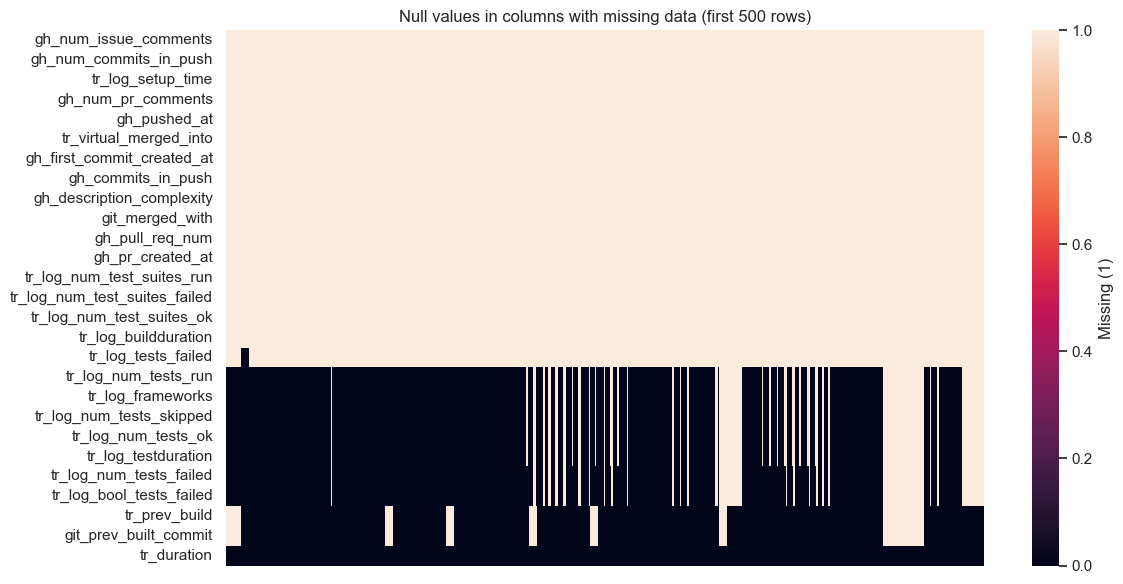

In [45]:
# Heatmap: columns with >0% missing (sample of rows for visibility)
cols_with_missing = missing_pct[missing_pct > 0].index.tolist()
if cols_with_missing:
    sample = df[cols_with_missing].head(500).isnull().astype(int)
    plt.figure(figsize=(12, 6))
    sns.heatmap(sample.T, cbar_kws={"label": "Missing (1)"}, yticklabels=True, xticklabels=False)
    plt.title("Null values in columns with missing data (first 500 rows)")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "01_null_heatmap.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("No columns with missing values.")

### Correlation matrix (numeric columns)

Correlation between numeric features. High correlation may inform feature selection or multicollinearity checks in modeling.

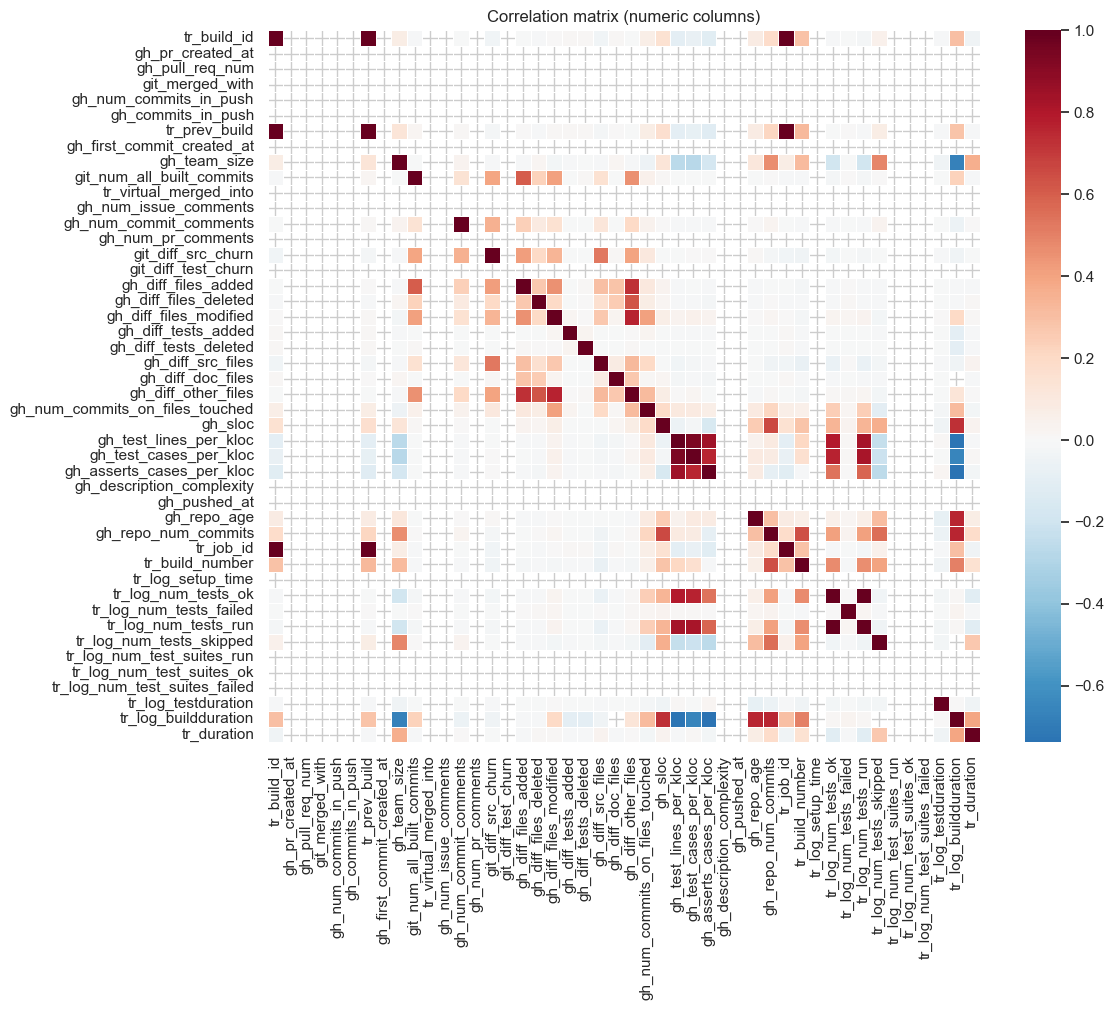

In [46]:
# Correlation matrix for numeric columns only
numeric_df = df.select_dtypes(include=[np.number])
if len(numeric_df.columns) > 1:
    corr = numeric_df.corr()
    plt.figure(figsize=(12, 10))
    sns.heatmap(corr, annot=False, cmap="RdBu_r", center=0, square=True, linewidths=0.5)
    plt.title("Correlation matrix (numeric columns)")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "01_correlation_matrix.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("Not enough numeric columns for correlation matrix.")

In [47]:
# Printed summary of the most important facts (for reader and dissertation)
print("=== DATA EXPLORATION SUMMARY ===\n")
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Target: tr_status (multi-class: passed, failed, errored, canceled)")
print(f"\nTarget distribution:\n{df['tr_status'].value_counts().to_string()}")
print(f"\nColumns with >10% missing: {(missing_pct > 10).sum()}")
print(f"Columns with >50% missing: {(missing_pct > 50).sum()}")
print("\nKey numeric columns for modeling: tr_duration, git_num_all_built_commits,")
print("git_diff_src_churn, git_diff_test_churn, gh_build_started_at (for temporal features).")
print("\nNext step: Notebook 2 — Data Processing (feature engineering, splits, encoders).")

=== DATA EXPLORATION SUMMARY ===

Shape: 100,000 rows × 66 columns
Target: tr_status (multi-class: passed, failed, errored, canceled)

Target distribution:
tr_status
passed     60461
failed     36928
errored     2611

Columns with >10% missing: 26
Columns with >50% missing: 17

Key numeric columns for modeling: tr_duration, git_num_all_built_commits,
git_diff_src_churn, git_diff_test_churn, gh_build_started_at (for temporal features).

Next step: Notebook 2 — Data Processing (feature engineering, splits, encoders).


### Summary

The above analysis gives a clear picture of the raw TravisTorrent data. **No transformation is performed in this notebook** — that is the role of Notebook 2 (Data Processing). Key takeaways: class imbalance (passed dominates), many columns with high missingness, and the presence of build duration, commit counts, churn, and timestamps that the literature identifies as predictive. All figures have been saved to `reports/figures`.